In [58]:
# we need it in all codes
import numpy as np 
import math
import matplotlib.pyplot as plt

# gradient method for minimizing f(x,y) = 2 x^2 - 4 xy + y^4
# now we have   nabla f = (4x - 4y, -4x + 4 y^3)

#initial vector
v = np.array([-0.1, -0.1])
# Be careful: we have to "refresh it in all boxes".


#learning rate
alpha = 0.2

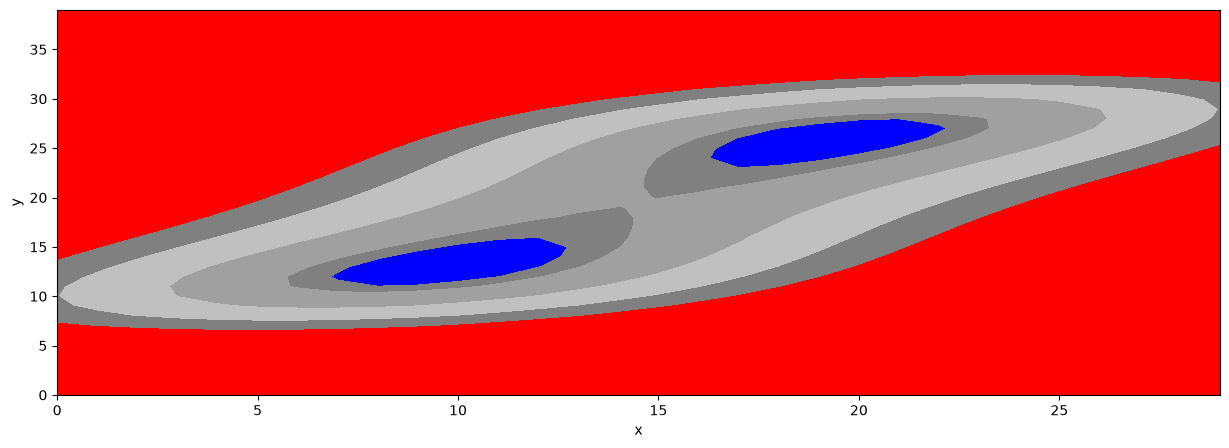

In [59]:
# A contour plot with the levels below. Function f(x,y) = 2x^2 -4xy +y^4.
#It will allow to see better local minima.

plt.rcParams["figure.figsize"] = (15,5)

# (x)_i = x_i coordinates i=0,..., 29
xlist = np.linspace(-3.0, 3.0, 30)
# (y)_j = y_j coordinates, j =0,..., 29
ylist = np.linspace(-3.0, 3.0, 40)

#Mesh grid allows us to create a grid of all possible combinations (xi,yj).
X, Y = np.meshgrid(xlist, ylist)

#Our fuction f(x,y):
h =2* X**2 - 4*X*Y + Y**4
plt.xlabel('x')
plt.ylabel('y')
#The graph of \Phi is in 3 dimensions, but it is enough for us to check their countour plots to see local minima
cs = plt.contourf(h, levels=[-0.5, 0, 2, 5, 8],
    colors=['#808080', '#A0A0A0', '#C0C0C0'], extend='both')
cs.cmap.set_over('red')
cs.cmap.set_under('blue')
cs.changed()


In [60]:
# Define its gradient (computed by hand) as a function 
def grad_f(x, y):
    return np.array([4*x - 4*y, -4*x + 4 * y**3])

#e.g gradient at a point (-1,-0.5), returns a vector:
grad_f(-1,-0.5)

array([-2. ,  3.5])

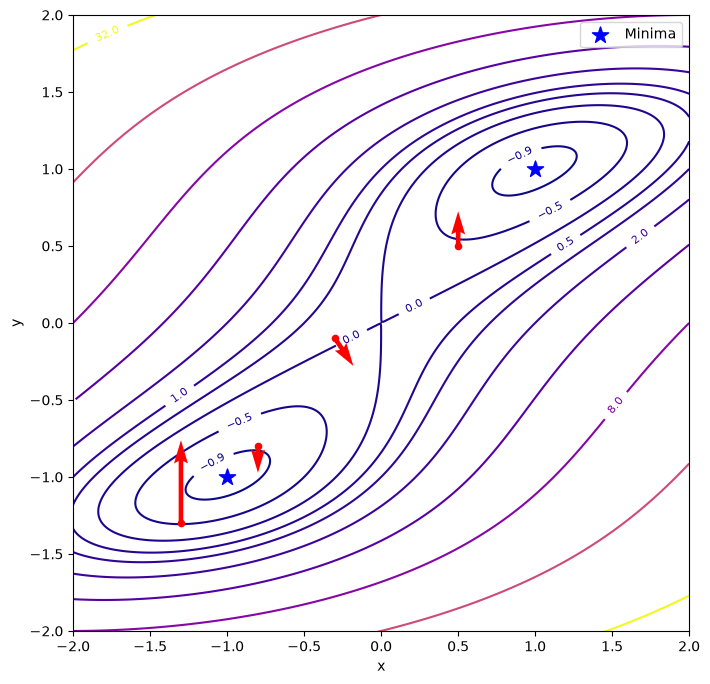

In [69]:
# Plot some gradient vectors. 
#plt.rcParams["figure.figsize"] = (15,5)
#plt.quiver( X,Y, U,V) where X,Y coord of where vector starts, (U,V) coodinates of vector

#Plotting for x_1 = -1.3 y_1 =-1.3.
#             x_2 = -0.3 y_2 = -0.1.
#             x_3 = -0.8, y_3 = -0.8.
#             x_4 = 0.5, y_4 = 0.5.

#We will visualize the first step of the gradient method at 4 different starting points

# The gradients -grad_f (x_i,y_i)[0] (horizontal component of -grad)
#               -grad_f (x_i,y_i)[1] (vertical component of -grad)

#We also draw in blue where one the local minimum is and mix it with the countour plot.
def f(x, y):
    return 2*x**2 - 4*x*y + y**4

# Grid for the contour plot
x = np.linspace(-3, 2, 400)
y = np.linspace(-3, 2, 400)
X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots(figsize=(8, 8))

contours = ax.contour(
    X, Y, f(X, Y),
    levels=[-0.9, -0.5, 0, 0.5, 1, 2, 4, 8, 16, 32],
    cmap="plasma"
)
ax.clabel(contours, inline=True, fontsize=8)

# Starting points
px = np.array([-1.3, -0.3, -0.8, 0.5])
py = np.array([-1.3, -0.1, -0.8, 0.5])

# Negative-gradient components
U = -grad_f(px,py)[0]#4*(py - px)
V = -grad_f(px,py)[1]# 4*(px - py**3)

# We change the magnitude of arrows so we can understand things more easily
alpha = 0.15
ax.quiver(
    px, py, alpha*U, alpha*V,
    angles="xy", scale_units="xy", scale=1,
    color="red", zorder=3
)
ax.scatter(px, py, color="red", s=20, zorder=4)

# Both minima
ax.scatter([-1, 1], [-1, 1], color="blue",
           marker="*", s=150, label="Minima", zorder=5)

ax.set(xlim=(-2, 2), ylim=(-2, 2), xlabel="x", ylabel="y")
ax.set_aspect("equal")
ax.legend()
plt.show()

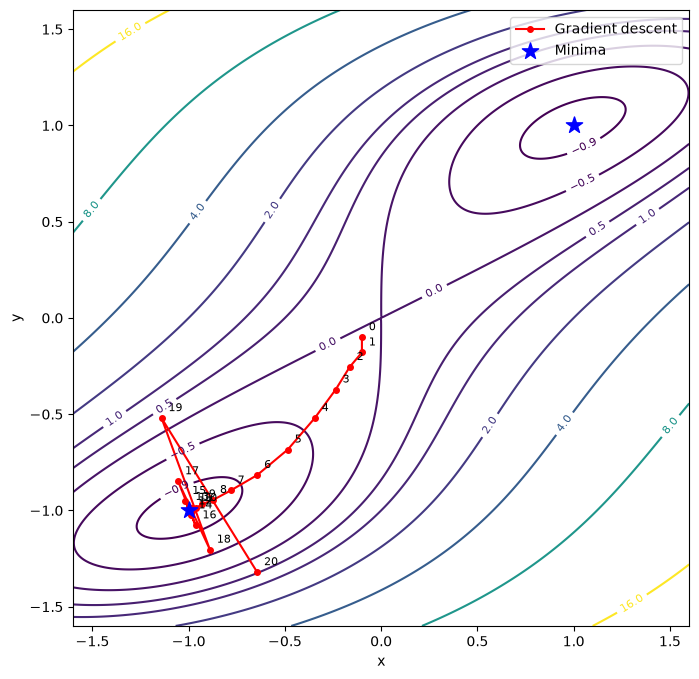

In [77]:
#We will visualize how the gradient method works. First, we draw again our countour plots
#we will show each update of the gradient method on this countour plot.
#==========================================================
# Contour plot
#==========================================================
x = np.linspace(-1.6, 1.6, 400)
y = np.linspace(-1.6, 1.6, 400)
X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots(figsize=(8, 8))

contours = ax.contour(
    X, Y, f(X, Y),
    levels=[-0.9, -0.5, 0, 0.5, 1, 2, 4, 8, 16],
    cmap="viridis"
)
ax.clabel(contours, fontsize=8)

#==========================================================
# Gradient descent algorithm with a fixed learning rate 
#==========================================================
alpha = 0.2
#Initial guess:
v = np.array([-0.1, -0.1])
# We will store the iterations v^(k) in points:
points = [v.copy()]

for j in range(20):
    v = v - alpha * grad_f(v[0], v[1])
    points.append(v.copy())

points = np.array(points)
#==========================================================
# Draw the path over the contours
#==========================================================
ax.plot(points[:, 0], points[:, 1], "-o",
        color="red", markersize=4, label="Gradient descent",
        zorder=3)
 
for j, (px, py) in enumerate(points): #enumerate(points) returns the index j and each point px[j], py[j]
    ax.annotate(str(j), (px, py), xytext=(5, 5),
                textcoords="offset points", fontsize=8)

# Mark both minima
ax.scatter([-1, 1], [-1, 1], marker="*", s=150,
           color="blue", label="Minima", zorder=4)

ax.set(xlabel="x", ylabel="y", xlim=(-1.6, 1.6), ylim=(-1.6, 1.6))
ax.set_aspect("equal")
ax.legend()
plt.show()

[-0.1    -0.1792]
[-0.16336    -0.25459633]
[-0.23634907 -0.37208213]
[-0.34493552 -0.51995102]
[-0.48494792 -0.68344482]
[-0.64374544 -0.81601523]
[-0.78156127 -0.89631644]
[-0.87336541 -0.94549703]
[-0.93107071 -0.96799663]
[-0.96061145 -0.98722939]
[-0.9819058  -0.98597827]
[-0.98516378 -1.0046854 ]
[-1.00078108 -0.98151869]
[-0.98537117 -1.025684  ]
[-1.01762144 -0.95074257]
[-0.96411834 -1.07733006]
[-1.05468771 -0.8483108 ]
[-0.88958618 -1.20368423]
[-1.14086462 -0.52018135]
[-0.64431801 -1.32026892]


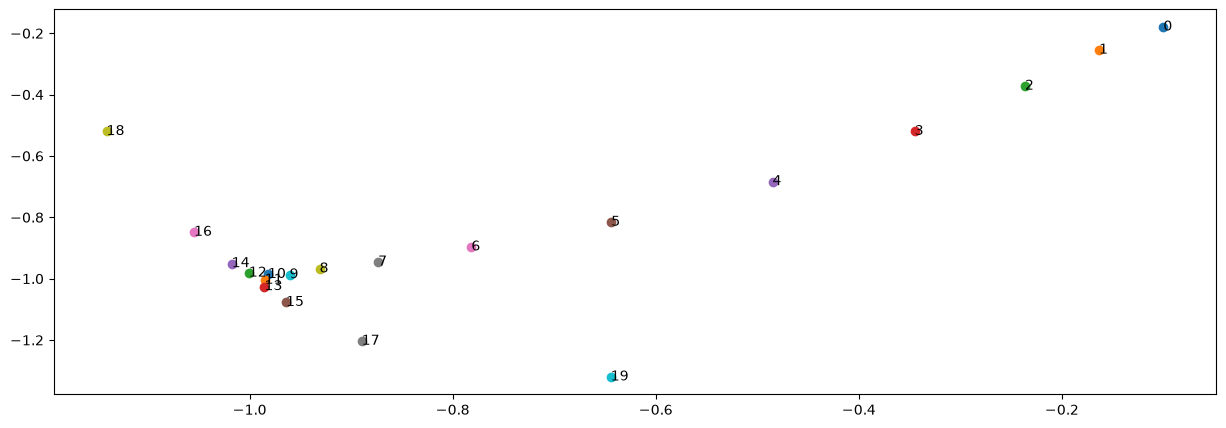

In [78]:
# the algorithm for 20 steps
# constant learning rate
alpha =0.2
v = np.array([-0.1, -0.1])
for j in range(20):

    #v = v - alpha * np.array( [4*v[0] - 4*v[1], -4*v[0] + 4*v[1]*v[1]*v[1]])
    v = v - alpha * grad_f(v[0],v[1])
    print(v)
    plt.plot(v[0], v[1], 'o')
    plt.text(v[0], v[1],j, ha="left", va="center")
    # with alpha = 0.2 it even does not converge
    # let us play with alpha

[-0.1    -0.1792]
[-0.14480229 -0.23251326]
[-0.18531425 -0.29358863]
[-0.228624   -0.35759206]
[-0.27476502 -0.42302763]
[-0.32318738 -0.4880414 ]
[-0.37303455 -0.55061524]
[-0.42326196 -0.60890929]
[-0.47276791 -0.66157498]
[-0.52053274 -0.70792355]
[-0.56573311 -0.74790463]
[-0.60780382 -0.78194155]
[-0.64644151 -0.81071923]
[-0.68156557 -0.83500443]
[-0.71325976 -0.85553091]
[-0.74171399 -0.87294458]
[-0.76717647 -0.88778816]
[-0.78991923 -0.90050673]
[-0.81021564 -0.91146127]
[-0.82832701 -0.92094373]


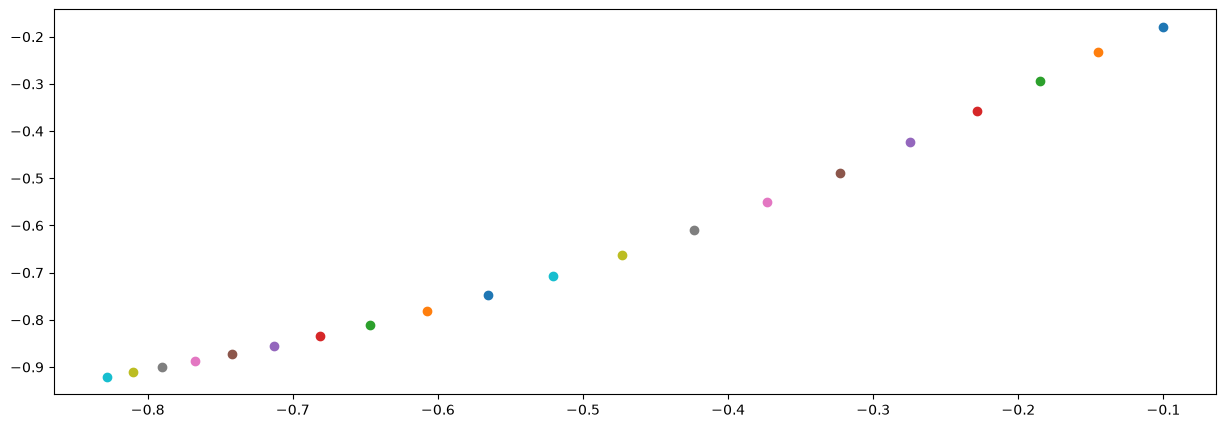

In [79]:
#Adding a a simple decaying learning rate
v = np.array([-0.1, -0.1])
for j in range(20):
    # the algorithm for 20 steps
    # simple decaying learning rate
    #v = v - alpha/(math.sqrt(j+1)) * np.array( [4*v[0] - 4*v[1], -4*v[0] + 4*v[1]*v[1]*v[1]])
    v = v - alpha/(math.sqrt(j+1)) * grad_f(v[0],v[1])
    print(v)
    plt.plot(v[0], v[1], 'o')

[-0.1 -0.2]
[-0.10696587 -0.2064086 ]
[-0.199335   -0.29759732]
[-0.31717219 -0.50503497]
[-0.62968357 -0.81836984]
[-1.17917247 -1.05599638]
[-0.95295117 -1.05893668]
[-1.00438699 -0.94513919]
[-0.98709785 -0.99185965]
[-0.98856046 -0.99533685]
[-0.9908523  -0.99617723]
[-0.99952399 -0.99988508]
[-1.00014054 -0.99966091]
[-0.99997702 -1.00005554]
[-1.00000002 -0.99999999]
[-1.00000001 -1.00000001]
[-1.00000001 -1.        ]
[-1. -1.]
[-1. -1.]
[-1. -1.]


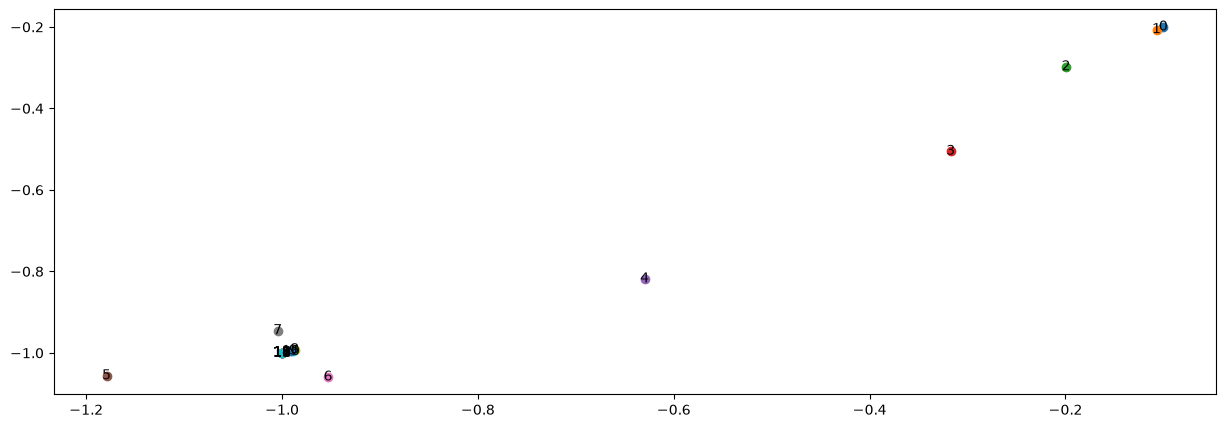

In [80]:
v = np.array([-0.1, -0.1])
grad_now = np.array([0,0])
v_prev = np.array([0,0])
for j in range(20):
    # the algorithm for 20 steps
    # a sophisticated decaying learning rate
    grad_prev = grad_now
    grad_now = grad_f(v[0],v[1])
    alpha = np.dot(grad_prev - grad_now, v_prev - v) / np.dot(grad_prev - grad_now, grad_prev - grad_now)
    v_prev = v
    v = v - abs(alpha) * grad_now
    print(v)
    plt.plot(v[0], v[1], 'o')
    plt.text(v[0], v[1],j, ha="center", va="center")

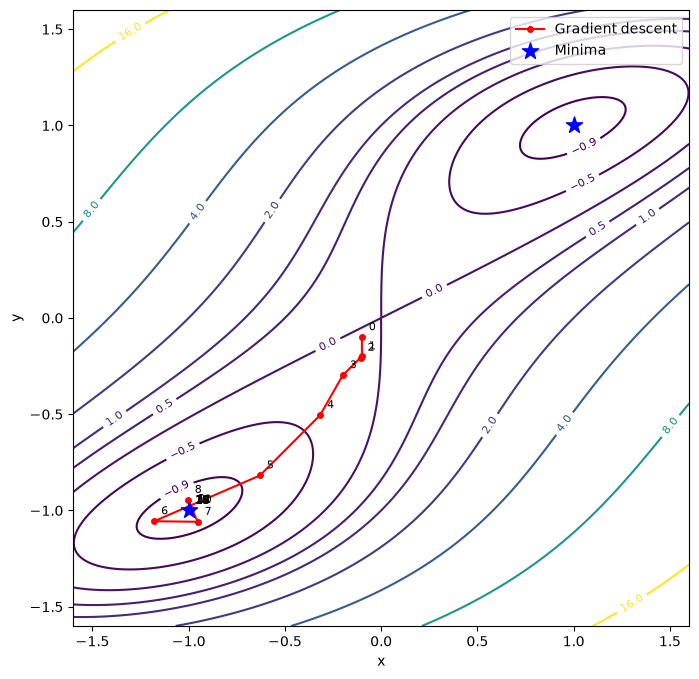

In [ ]:
#We will visualize how the gradient method works. First, we draw again our countour plots
#we will show each update of the gradient method on this countour plot.
#==========================================================
# Contour plot
#==========================================================
x = np.linspace(-1.6, 1.6, 400)
y = np.linspace(-1.6, 1.6, 400)
X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots(figsize=(8, 8))

contours = ax.contour(
    X, Y, f(X, Y),
    levels=[-0.9, -0.5, 0, 0.5, 1, 2, 4, 8, 16],
    cmap="viridis"
)
ax.clabel(contours, fontsize=8)

#==========================================================
# Gradient descent algorithm with a sophisticated learning rate 
#==========================================================
# #Initial guess:
v = np.array([-0.1, -0.1])
# We will store the iterations v^(k) in points:
points = [v.copy()]
#At the first step, to obtain alpha_0 using the formula from the notes, we will take our initial guess
#v and another initial guess v_prev. Then s^0 = v, and s^-1 = [0,0]

#Auxiliary points to find the first alpha.
grad_now = np.array([0,0])
v_prev = np.array([0,0])
for j in range(20):
    # a sophisticated decaying learning rate
    grad_prev = grad_now
    grad_now = grad_f(v[0],v[1])
    #alpha = <grad_i-grad_i+1, v_i -v_i+1> / |grad_i-grad_i+1|^2
    alpha = np.dot(grad_prev - grad_now, v_prev - v) / np.dot(grad_prev - grad_now, grad_prev - grad_now)
    v_prev = v
    v = v - abs(alpha) * grad_now
    points.append(v.copy())

points = np.array(points)
#==========================================================
# Draw the path over the contours
#==========================================================
ax.plot(points[:, 0], points[:, 1], "-o",
        color="red", markersize=4, label="Gradient descent",
        zorder=3)
 
for j, (px, py) in enumerate(points): #enumerate(points) returns the index j and each point px[j], py[j]
    ax.annotate(str(j), (px, py), xytext=(5, 5),
                textcoords="offset points", fontsize=8)

# Mark both minima
ax.scatter([-1, 1], [-1, 1], marker="*", s=150,
           color="blue", label="Minima", zorder=4)

ax.set(xlabel="x", ylabel="y", xlim=(-1.6, 1.6), ylim=(-1.6, 1.6))
ax.set_aspect("equal")
ax.legend()
plt.show()